### Insurance Claims Denial Prediction - Exploratory Data Analysis

#### Objective
The objective of this notebook is to understand the historical claims dataset, identify data quality issues, explore relationships between features and claim denial, and generate business insights that will guide feature engineering and model development.

In [7]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [8]:
df=pd.read_csv("../data/claims_history.csv")

In [12]:

df.head()

,claim_id,payer_id,payer_type,visit_type,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,split,service_month,is_denied,denial_reason
0,HCLM-00001,P008,Medicaid MCO,Outpatient,4311.44,1404.82,2,5,0,0,1,13,0,1,0,0,train,2024-06,1,Payer policy or medical necessity issue
1,HCLM-00002,P001,Commercial,Inpatient,10420.64,6065.91,6,8,1,1,0,19,0,1,1,1,train,2024-06,0,NaN
2,HCLM-00003,P010,BCBS,Outpatient,38369.33,20712.61,5,5,0,0,0,50,1,1,0,0,train,2024-02,1,Documentation incomplete or missing
3,HCLM-00004,P005,Medicare Advantage,Outpatient,6268.92,2306.49,6,3,1,1,1,7,0,1,1,1,validation,2024-09,0,NaN
4,HCLM-00005,P008,Medicaid MCO,Emergency,3986.26,1247.93,8,7,0,1,1,17,0,0,1,1,validation,2024-09,1,Patient eligibility could not be verified


In [3]:
#checking rows and columns
df.shape

(3200, 20)

In [4]:
#checking datatypes and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   claim_id                    3200 non-null   str    
 1   payer_id                    3200 non-null   str    
 2   payer_type                  3200 non-null   str    
 3   visit_type                  3200 non-null   str    
 4   total_billed                3200 non-null   float64
 5   expected_payment            3200 non-null   float64
 6   num_procedures              3200 non-null   int64  
 7   num_diagnoses               3200 non-null   int64  
 8   prior_auth_required         3200 non-null   int64  
 9   has_prior_auth              3200 non-null   int64  
 10  is_in_network               3200 non-null   int64  
 11  days_to_submit              3200 non-null   int64  
 12  missing_documentation_flag  3200 non-null   int64  
 13  eligibility_verified        3200 non-null   

In [5]:
#Summary Statistics for Numerical Columns
df.describe()

,total_billed,expected_payment,num_procedures,num_diagnoses,prior_auth_required,has_prior_auth,is_in_network,days_to_submit,missing_documentation_flag,eligibility_verified,referral_required,referral_present,is_denied
count,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,12164.406722,6032.162956,3.848438,5.315938,0.380000,0.394375,0.817813,19.267187,0.188750,0.868750,0.284062,0.237187,0.215938
std,13173.400467,6697.618117,2.122793,2.594484,0.485462,0.488792,0.386059,11.777777,0.391371,0.337726,0.451037,0.425425,0.411535
min,522.630000,192.700000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4401.085000,2065.390000,2.000000,3.000000,0.000000,0.000000,1.000000,11.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,7972.490000,3849.820000,3.000000,5.000000,0.000000,0.000000,1.000000,17.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,14847.200000,7421.650000,5.000000,7.000000,1.000000,1.000000,1.000000,25.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,95000.000000,62988.930000,15.000000,18.000000,1.000000,1.000000,1.000000,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
#Target distribution
df["is_denied"].value_counts()

is_denied
0    2509
1     691
Name: count, dtype: int64

In [7]:
df["is_denied"].value_counts(normalize=True)*100

is_denied
0    78.40625
1    21.59375
Name: proportion, dtype: float64

#### Finding- Dataset is moderately imbalanced. Approximately 21.6% of historical claims were denied while 78.4% were approved.

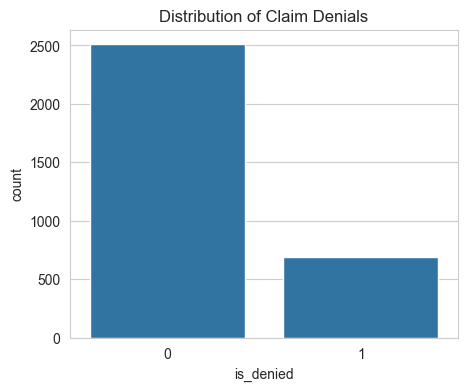

In [8]:
plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="is_denied"
)

plt.title("Distribution of Claim Denials")

plt.show()

In [9]:
# Number of observations in train/validation/test dataset split
df["split"].value_counts()

split
train         2122
validation     539
test           539
Name: count, dtype: int64

In [10]:
df.groupby("split")["is_denied"].mean()

split
test          0.259740
train         0.211122
validation    0.191095
Name: is_denied, dtype: float64

In [11]:
#Categorical columns
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

/var/folders/jc/m929xgk50j75ght983sl49dm0000gn/T/ipykernel_40313/4065310798.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['claim_id', 'payer_id', 'payer_type', 'visit_type', 'split',
       'service_month', 'denial_reason'],
      dtype='str')

In [12]:
#Check frequency counts for categorical columns
for col in categorical_cols:
    print("="*50)
    print(col)
    print(df[col].value_counts())

claim_id
claim_id
HCLM-00001    1
HCLM-00002    1
HCLM-00003    1
HCLM-00004    1
HCLM-00005    1
             ..
HCLM-03196    1
HCLM-03197    1
HCLM-03198    1
HCLM-03199    1
HCLM-03200    1
Name: count, Length: 3200, dtype: int64
payer_id
payer_id
P011    329
P001    307
P009    300
P005    284
P012    277
P006    274
P007    273
P003    252
P002    248
P008    229
P010    217
P004    210
Name: count, dtype: int64
payer_type
payer_type
Commercial            1346
Medicaid MCO           779
Medicare Advantage     558
BCBS                   517
Name: count, dtype: int64
visit_type
visit_type
Outpatient     1477
Emergency       673
Inpatient       664
Observation     386
Name: count, dtype: int64
split
split
train         2122
validation     539
test           539
Name: count, dtype: int64
service_month
service_month
2024-11    288
2024-10    283
2024-06    281
2024-03    279
2024-01    274
2024-08    270
2024-04    262
2024-09    256
2024-07    256
2024-05    255
2024-12    251
2024-0

In [13]:
#Numerical Columns

numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

numerical_cols

Index(['total_billed', 'expected_payment', 'num_procedures', 'num_diagnoses',
       'prior_auth_required', 'has_prior_auth', 'is_in_network',
       'days_to_submit', 'missing_documentation_flag', 'eligibility_verified',
       'referral_required', 'referral_present', 'is_denied'],
      dtype='str')

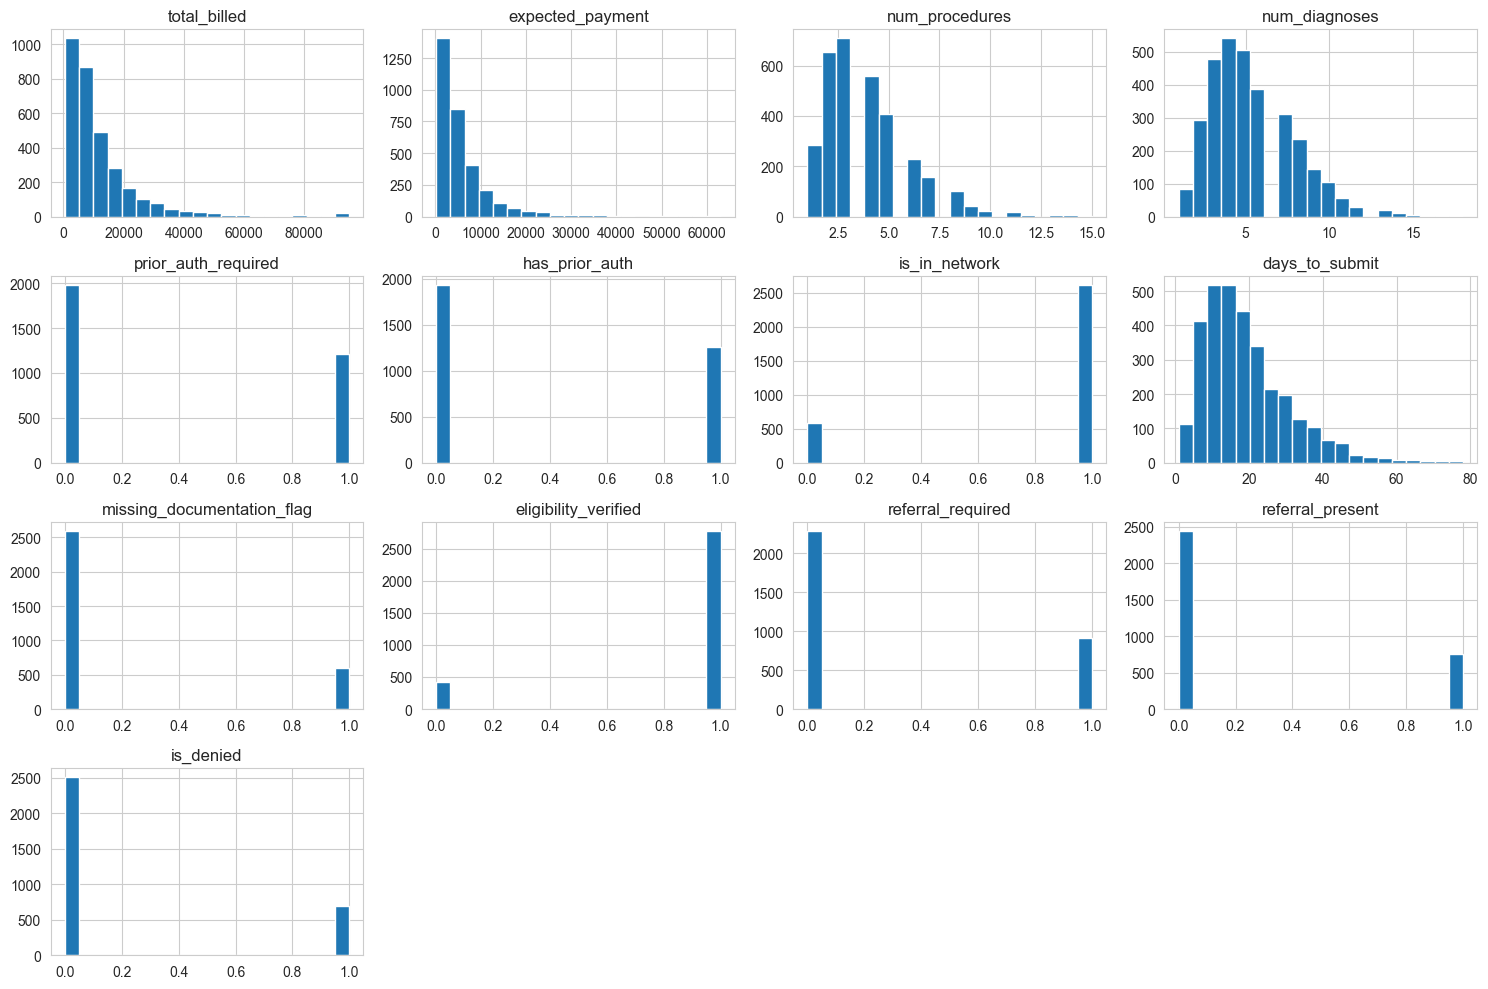

In [14]:
#Plotting Histogram for checking distributions

df[numerical_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()

plt.show()

In [15]:
#Checking Coorelation

corr = df.drop(
    columns=["is_denied"]
).select_dtypes(include=np.number)

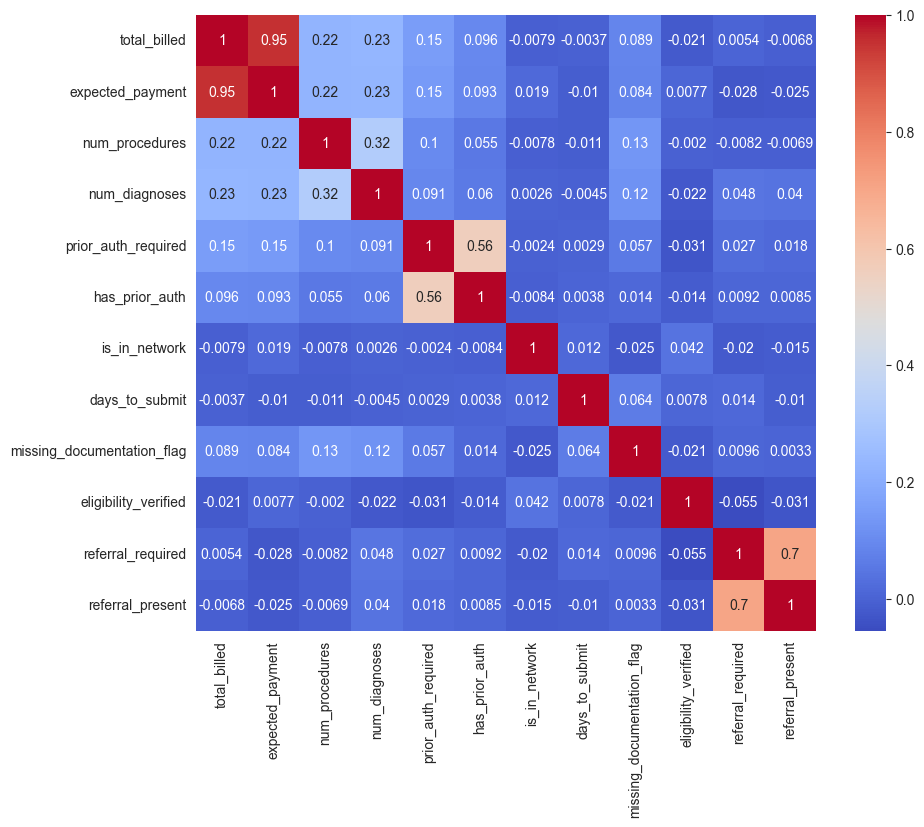

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

#### Relationship with Target

In [17]:
def analyze_categorical_feature(df, feature, target="is_denied"):
    """
    Analyze relationship between a categorical feature and target variable.

    Parameters
    ----------
    df : pandas DataFrame
    feature : str
        Categorical column name
    target : str
        Target column (is_denied)
    """

    # Calculate denial rate
    summary = (
        df.groupby(feature)[target]
          .agg(["count", "mean"])
          .reset_index()
          .rename(columns={
              "count": "Total Claims",
              "mean": "Denial Rate"
          })
    )

    summary["Denial Rate"] = (summary["Denial Rate"] * 100).round(2)

    print(f"\nRelationship between {feature} and {target}")
    display(summary)

    # Plot
    plt.figure(figsize=(7,4))

    sns.barplot(
        data=summary,
        x=feature,
        y="Denial Rate"
    )

    plt.title(f"Denial Rate by {feature}")
    plt.ylabel("Denial Rate (%)")
    plt.xticks(rotation=45)
    plt.show()




Relationship between payer_id and is_denied


,payer_id,Total Claims,Denial Rate
0,P001,307,11.07
1,P002,248,16.94
2,P003,252,20.63
3,P004,210,15.24
4,P005,284,23.59
5,P006,274,27.37
6,P007,273,29.67
7,P008,229,37.12
8,P009,300,19.67
9,P010,217,23.50


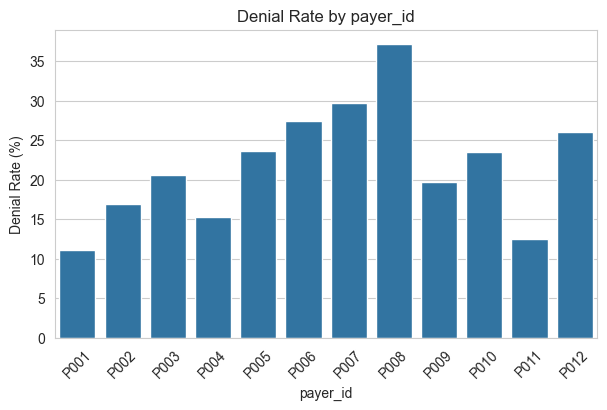

In [18]:
analyze_categorical_feature(df, "payer_id")


Relationship between payer_type and is_denied


,payer_type,Total Claims,Denial Rate
0,BCBS,517,21.28
1,Commercial,1346,14.93
2,Medicaid MCO,779,30.55
3,Medicare Advantage,558,25.45


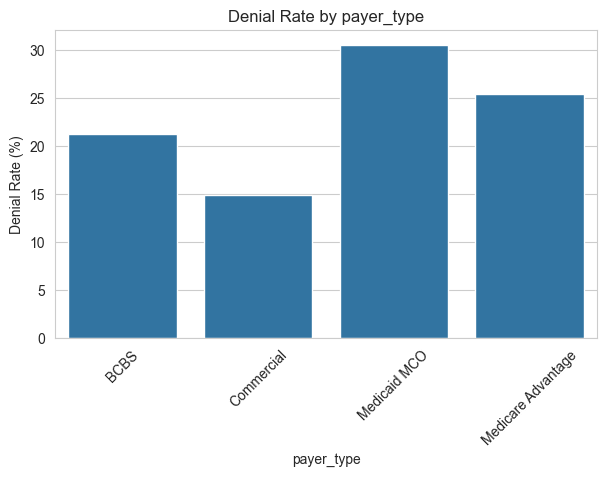

In [19]:
analyze_categorical_feature(df, "payer_type")


Relationship between visit_type and is_denied


,visit_type,Total Claims,Denial Rate
0,Emergency,673,18.28
1,Inpatient,664,30.57
2,Observation,386,18.13
3,Outpatient,1477,19.97


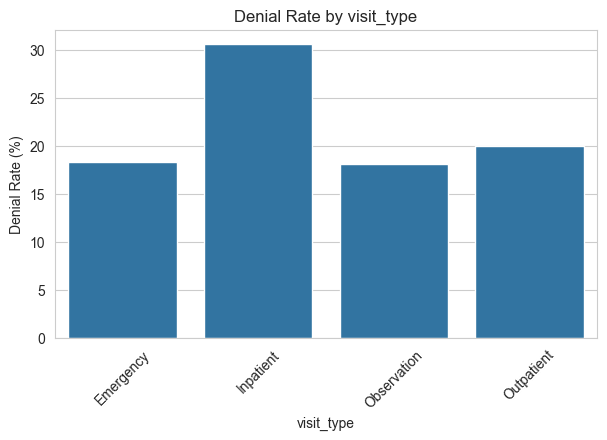

In [20]:
analyze_categorical_feature(df, "visit_type")


Relationship between is_in_network and is_denied


,is_in_network,Total Claims,Denial Rate
0,0,583,24.87
1,1,2617,20.86


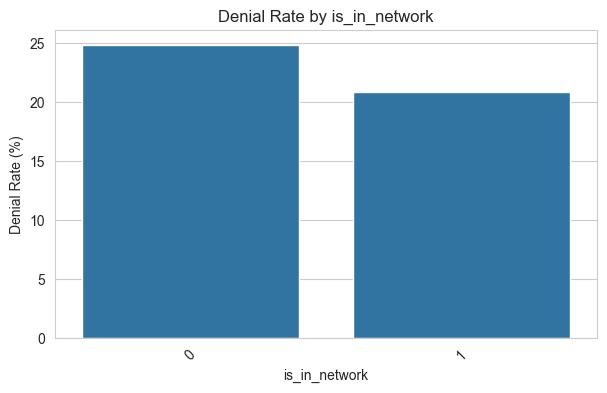

In [21]:
analyze_categorical_feature(df, "is_in_network")


Relationship between missing_documentation_flag and is_denied


,missing_documentation_flag,Total Claims,Denial Rate
0,0,2596,17.64
1,1,604,38.58


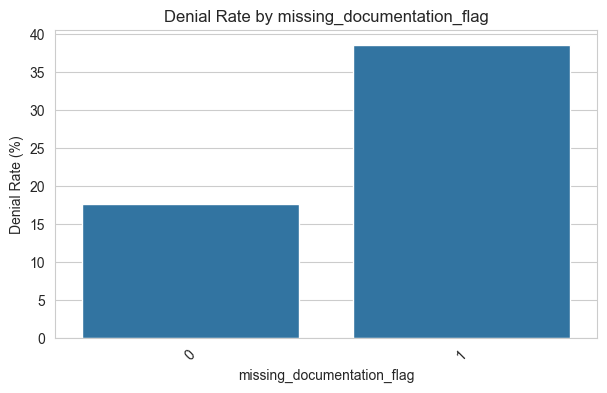

In [22]:
analyze_categorical_feature(df, "missing_documentation_flag")


Relationship between eligibility_verified and is_denied


,eligibility_verified,Total Claims,Denial Rate
0,0,420,35.95
1,1,2780,19.42


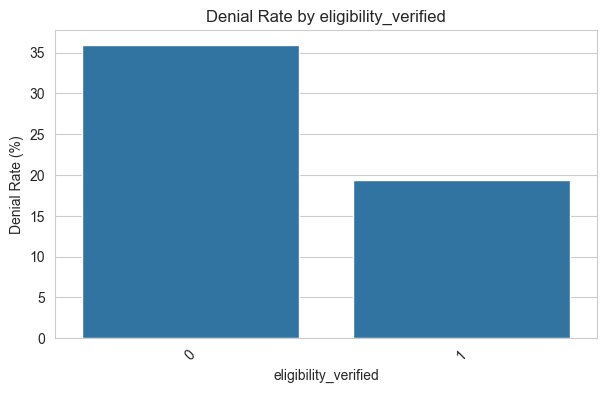

In [23]:
analyze_categorical_feature(df, "eligibility_verified")


Relationship between prior_auth_required and is_denied


,prior_auth_required,Total Claims,Denial Rate
0,0,1984,18.40
1,1,1216,26.81


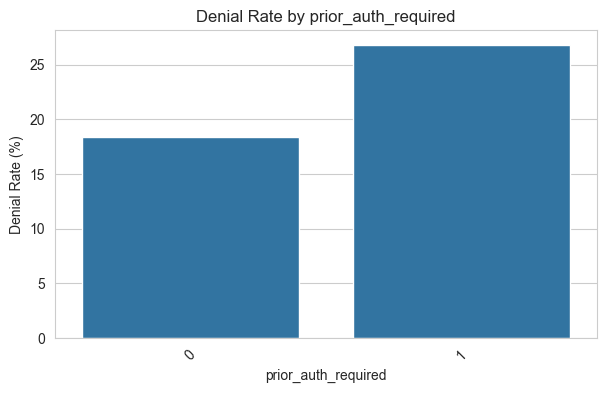

In [24]:
analyze_categorical_feature(df, "prior_auth_required")


Relationship between has_prior_auth and is_denied


,has_prior_auth,Total Claims,Denial Rate
0,0,1938,22.55
1,1,1262,20.13


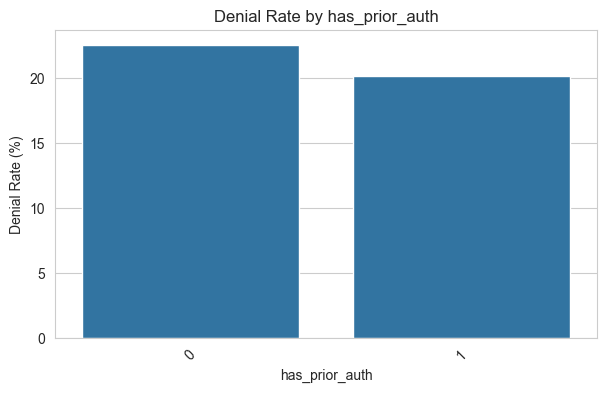

In [25]:
analyze_categorical_feature(df, "has_prior_auth")


Relationship between referral_required and is_denied


,referral_required,Total Claims,Denial Rate
0,0,2291,20.52
1,1,909,24.31


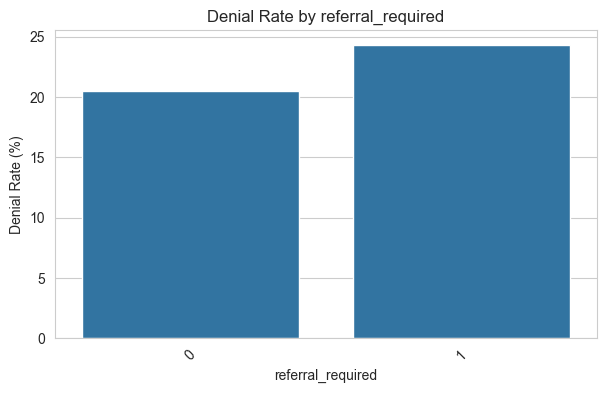

In [26]:
analyze_categorical_feature(df, "referral_required")


Relationship between referral_present and is_denied


,referral_present,Total Claims,Denial Rate
0,0,2441,21.79
1,1,759,20.95


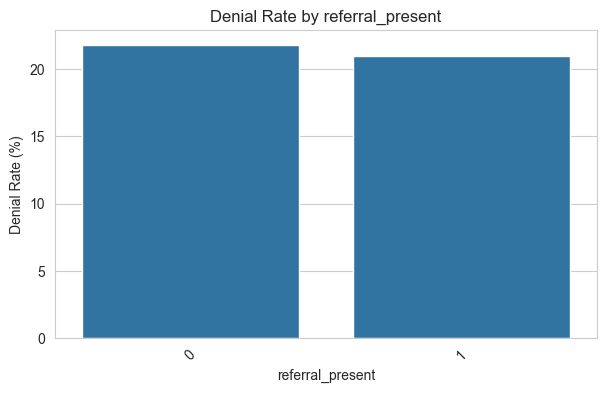

In [27]:
analyze_categorical_feature(df, "referral_present")

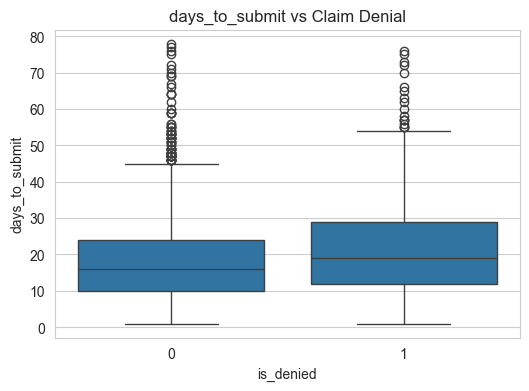

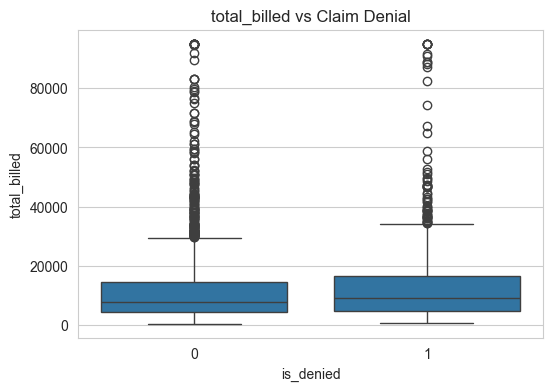

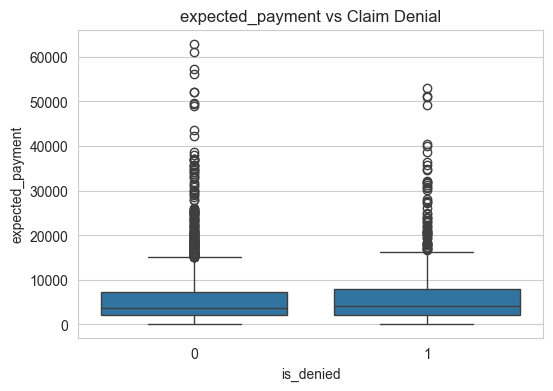

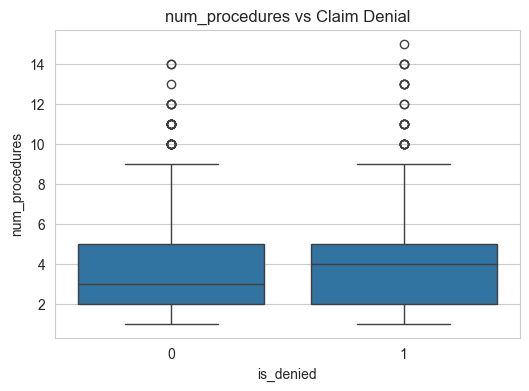

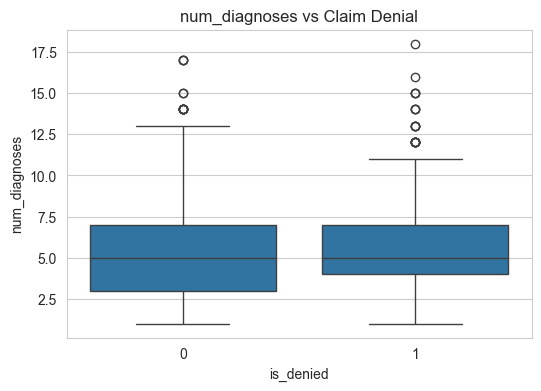

In [28]:
#Boxplots
numeric_features = [
    "days_to_submit",
    "total_billed",
    "expected_payment",
    "num_procedures",
    "num_diagnoses"
]

for feature in numeric_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="is_denied",
        y=feature
    )

    plt.title(f"{feature} vs Claim Denial")

    plt.show()

#### New Feature - Claims where authorization was required but not available


Relationship between auth_missing and is_denied


,auth_missing,Total Claims,Denial Rate
0,False,2890,18.93
1,True,310,46.45


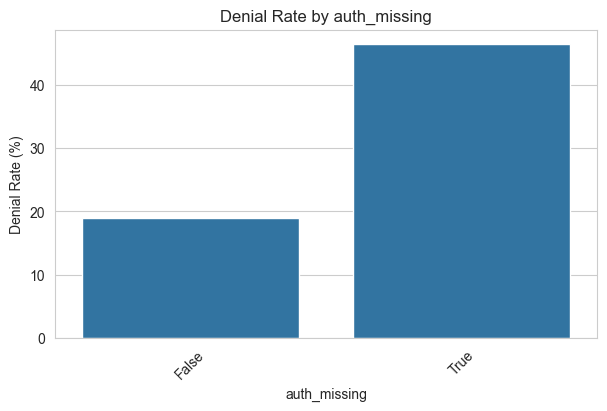

In [29]:
# Claims where authorization was required but not available
df["auth_missing"] = (
    (df["prior_auth_required"] == 1) &
    (df["has_prior_auth"] == 0)
)
analyze_categorical_feature(df, "auth_missing")

#### New Feature: Referral required but missing


Relationship between referral_missing and is_denied


,referral_missing,Total Claims,Denial Rate
0,False,2939,20.59
1,True,261,32.95


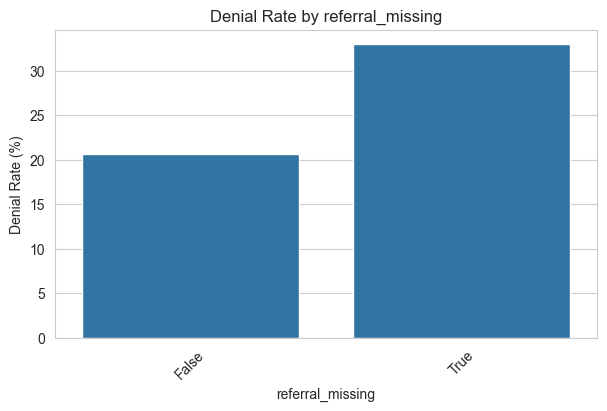

In [30]:
df["referral_missing"] = (
    (df["referral_required"] == 1) &
    (df["referral_present"] == 0)
)

analyze_categorical_feature(df, "referral_missing")

### Top Business Insights

### 1. Overall Denial Trend
- Approximately **22% of historical claims were denied**, indicating a moderately imbalanced classification problem.
- Model evaluation should therefore prioritize ranking metrics (ROC-AUC) and the ability to identify high-risk claims rather than accuracy alone.

### 2. Payer Characteristics
- **Medicaid MCO (30.6%)** and **Medicare Advantage (25.5%)** exhibit the highest denial rates among payer types.
- Denial rates also vary considerably across individual payer IDs (11%–37%), indicating that payer-specific behavior is an important predictor of claim denial.

### 3. Visit Type
- **Inpatient claims (30.6%)** have a substantially higher denial rate compared with Emergency, Observation and Outpatient visits (~18–20%).
- Visit type is therefore expected to be an important predictive feature.

### 4. Operational Process Factors
Several operational variables demonstrate a strong relationship with claim denial:
- Claims with **missing documentation** have more than twice the denial rate (38.6%) compared with complete documentation (17.6%).
- Claims where **eligibility is not verified** show a denial rate of **36.0%**, compared with **19.4%** when eligibility is verified.
- Claims requiring **prior authorization** have higher denial rates (26.8%) than those that do not (18.4%).

### 5. Strongest Predictive Signals
The strongest business indicators identified during EDA are:
- **Missing prior authorization when authorization is required** (46.5% denial rate)
- **Missing referral when required** (33.0%)

These operational factors appear to be the most influential drivers of claim denial.

### 6. Financial and Numerical Features
Among the numerical variables:
- **Days to submit** shows a clear relationship with claim denial, with denied claims being submitted later on average (median: 19 days vs. 16 days for approved claims).
- Other numerical variables such as billed amount, expected payment, number of procedures and number of diagnoses show considerable overlap between approved and denied claims and are expected to contribute more when combined with operational features.

### 7. Overall Conclusion
The EDA indicates that **operational workflow factors** including authorization, documentation, eligibility verification and referrals are stronger predictors of claim denial than financial variables alone. These insights directly guide the feature engineering and model development in the next stage of the project.